# 04 YOLO11n Result Review and Model Selection

03 Colab 노트북에서 학습한 YOLO11n 표지판 탐지 모델 결과를 local에서 검토함.

비교 대상:

- `clean_v1`: 증강 없는 baseline
- `light_aug_v2`: Roboflow light augmentation 적용 버전

이번 노트북의 목적:

- Colab output이 정상적으로 내려왔는지 확인함.
- train/validation/test metric을 비교함.
- confusion matrix와 prediction preview를 확인함.
- Pi 탑재 후보 모델을 1개 고름.


## 0. 실행 설정

Colab output은 아래 폴더에 보관되어 있다고 가정함.

```text
10_experiments/07_sign_detection_yolo/colab_outputs/yolo11n_field2_20260507
```


In [1]:
from pathlib import Path
import json
import csv

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '07_sign_detection_yolo'
OUTPUT_ROOT = EXP_ROOT / 'colab_outputs' / 'yolo11n_field2_20260507'
REVIEW_ROOT = EXP_ROOT / 'review_outputs' / '04_yolo11n_result_review'
TABLE_DIR = REVIEW_ROOT / 'tables'
GRID_DIR = REVIEW_ROOT / 'grids'

for p in [TABLE_DIR, GRID_DIR]:
    p.mkdir(parents=True, exist_ok=True)

RUNS = {
    'clean_v1': OUTPUT_ROOT / 'field2_clean_v1_yolo11n',
    'light_aug_v2': OUTPUT_ROOT / 'field2_light_aug_v2_yolo11n',
}

print('OUTPUT_ROOT:', OUTPUT_ROOT)
for k, p in RUNS.items():
    print(k, p, 'exists=', p.exists())


OUTPUT_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\colab_outputs\yolo11n_field2_20260507
clean_v1 ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\colab_outputs\yolo11n_field2_20260507\field2_clean_v1_yolo11n exists= True
light_aug_v2 ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\colab_outputs\yolo11n_field2_20260507\field2_light_aug_v2_yolo11n exists= True


## 1. 산출물 존재 확인

각 run마다 최소한 아래 파일이 있어야 함.

- `weights/best.pt`
- `weights/best.onnx`
- `results.csv`
- `confusion_matrix.png`
- `results.png`


In [2]:
artifact_rows = []
for key, run_dir in RUNS.items():
    for rel in ['weights/best.pt', 'weights/last.pt', 'weights/best.onnx', 'results.csv', 'results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png']:
        path = run_dir / rel
        artifact_rows.append({
            'dataset_key': key,
            'artifact': rel,
            'exists': path.exists(),
            'size_mb': path.stat().st_size / 1024 / 1024 if path.exists() else None,
            'path': str(path),
        })
artifact_df = pd.DataFrame(artifact_rows)
display(artifact_df)
artifact_df.to_csv(TABLE_DIR / 'artifact_inventory.csv', index=False, encoding='utf-8-sig')
assert artifact_df[artifact_df['artifact'].isin(['weights/best.pt','weights/best.onnx','results.csv'])]['exists'].all()


,dataset_key,artifact,exists,size_mb,path
0,clean_v1,weights/best.pt,True,5.236833,~\02_Projects\University\26-1_Em...
1,clean_v1,weights/last.pt,True,5.236833,~\02_Projects\University\26-1_Em...
2,clean_v1,weights/best.onnx,True,10.116575,~\02_Projects\University\26-1_Em...
3,clean_v1,results.csv,True,0.009544,~\02_Projects\University\26-1_Em...
4,clean_v1,results.png,True,0.299561,~\02_Projects\University\26-1_Em...
5,clean_v1,confusion_matrix.png,True,0.126190,~\02_Projects\University\26-1_Em...
6,clean_v1,confusion_matrix_normalized.png,True,0.134180,~\02_Projects\University\26-1_Em...
7,light_aug_v2,weights/best.pt,True,5.236833,~\02_Projects\University\26-1_Em...
8,light_aug_v2,weights/last.pt,True,5.236833,~\02_Projects\University\26-1_Em...
9,light_aug_v2,weights/best.onnx,True,10.116579,~\02_Projects\University\26-1_Em...


## 2. Train Summary와 Test Summary 읽기

03 노트북이 저장한 summary CSV를 읽음.

중요하게 볼 지표:

- `mAP50`: IoU 0.5 기준 탐지 성능. 표지판 위치를 대략 잘 잡는지 확인.
- `mAP50-95`: 더 엄격한 bbox 품질. 박스가 얼마나 정밀한지 확인.
- `precision`: 잘못된 탐지를 얼마나 적게 하는지.
- `recall`: 실제 표지판을 얼마나 놓치지 않는지.

자동차 제어에서는 recall이 중요함. 표지판을 놓치면 명령 자체를 못 받기 때문임. 다만 false positive가 너무 많으면 잘못된 제어가 발생하므로 precision도 함께 봐야 함.


In [3]:
train_summary_path = OUTPUT_ROOT / 'field2_yolo11n_train_summary.csv'
test_summary_path = OUTPUT_ROOT / 'field2_yolo11n_test_eval_summary.csv'
onnx_export_path = OUTPUT_ROOT / 'field2_yolo11n_onnx_exports.csv'

train_summary_df = pd.read_csv(train_summary_path)
test_summary_df = pd.read_csv(test_summary_path)
onnx_export_df = pd.read_csv(onnx_export_path)

display(train_summary_df)
display(test_summary_df)
display(onnx_export_df)

train_summary_df.to_csv(TABLE_DIR / 'train_summary_copy.csv', index=False, encoding='utf-8-sig')
test_summary_df.to_csv(TABLE_DIR / 'test_summary_copy.csv', index=False, encoding='utf-8-sig')


,dataset_key,run_name,run_dir,best_pt,last_pt,data_yaml,results_csv,exists,best_epoch_by_mAP50,best_epoch,...,best_metrics/mAP50-95(B),last_metrics/mAP50-95(B),best_train/box_loss,last_train/box_loss,best_train/cls_loss,last_train/cls_loss,best_val/box_loss,last_val/box_loss,best_val/cls_loss,last_val/cls_loss
0,clean_v1,field2_clean_v1_yolo11n,/content/drive/MyDrive/Colab Notebooks/26-1학기_...,/content/drive/MyDrive/Colab Notebooks/26-1학기_...,/content/drive/MyDrive/Colab Notebooks/26-1학기_...,/content/sign_yolo11n_field2/sanitized_dataset...,/content/drive/MyDrive/Colab Notebooks/26-1학기_...,True,29,30.0,...,0.66609,0.68967,1.19746,1.12100,0.55186,0.43267,1.21948,1.17250,0.50536,0.40614
1,light_aug_v2,field2_light_aug_v2_yolo11n,/content/drive/MyDrive/Colab Notebooks/26-1학기_...,/content/drive/MyDrive/Colab Notebooks/26-1학기_...,/content/drive/MyDrive/Colab Notebooks/26-1학기_...,/content/sign_yolo11n_field2/sanitized_dataset...,/content/drive/MyDrive/Colab Notebooks/26-1학기_...,True,25,26.0,...,0.66212,0.67889,1.18121,1.08928,0.51780,0.40000,1.23221,1.17589,0.47760,0.39080


,dataset_key,run_name,best_pt,test_map50,test_map50_95,test_precision_mean,test_recall_mean
0,clean_v1,field2_clean_v1_yolo11n,/content/drive/MyDrive/Colab Notebooks/26-1학기_...,0.993071,0.697306,0.988706,0.978649
1,light_aug_v2,field2_light_aug_v2_yolo11n,/content/drive/MyDrive/Colab Notebooks/26-1학기_...,0.993722,0.700777,0.984186,0.994506


,dataset_key,run_name,best_pt,onnx_path
0,clean_v1,field2_clean_v1_yolo11n,/content/drive/MyDrive/Colab Notebooks/26-1학기_...,/content/drive/MyDrive/Colab Notebooks/26-1학기_...
1,light_aug_v2,field2_light_aug_v2_yolo11n,/content/drive/MyDrive/Colab Notebooks/26-1학기_...,/content/drive/MyDrive/Colab Notebooks/26-1학기_...


## 3. 핵심 metric 비교표

test split 기준으로는 `light_aug_v2`가 근소하게 높았음.

단, clean과 aug 모두 mAP50이 0.99 이상이라서 성능 차이는 큰 차이가 아니라 작은 우세로 해석함.


,dataset_key,best_epoch_by_mAP50,val_best_mAP50,val_best_mAP50_95,test_mAP50,test_mAP50_95,test_precision_mean,test_recall_mean
0,clean_v1,29,0.99478,0.66609,0.993071,0.697306,0.988706,0.978649
1,light_aug_v2,25,0.99464,0.66212,0.993722,0.700777,0.984186,0.994506


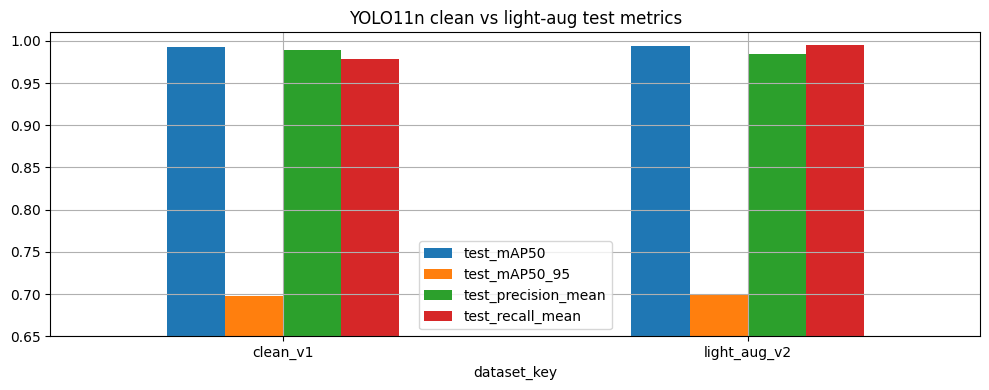

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\04_yolo11n_result_review\grids\metric_comparison_bar.png


In [4]:
metric_rows = []
for _, row in test_summary_df.iterrows():
    dataset_key = row['dataset_key']
    train_row = train_summary_df[train_summary_df['dataset_key'] == dataset_key].iloc[0]
    metric_rows.append({
        'dataset_key': dataset_key,
        'best_epoch_by_mAP50': train_row.get('best_epoch_by_mAP50'),
        'val_best_mAP50': train_row.get('best_metrics/mAP50(B)'),
        'val_best_mAP50_95': train_row.get('best_metrics/mAP50-95(B)'),
        'test_mAP50': row.get('test_map50'),
        'test_mAP50_95': row.get('test_map50_95'),
        'test_precision_mean': row.get('test_precision_mean'),
        'test_recall_mean': row.get('test_recall_mean'),
    })
metric_df = pd.DataFrame(metric_rows)
display(metric_df)
metric_df.to_csv(TABLE_DIR / 'metric_comparison.csv', index=False, encoding='utf-8-sig')

ax = metric_df.set_index('dataset_key')[['test_mAP50', 'test_mAP50_95', 'test_precision_mean', 'test_recall_mean']].plot(kind='bar', figsize=(10,4), ylim=(0.65, 1.01), grid=True)
plt.title('YOLO11n clean vs light-aug test metrics')
plt.xticks(rotation=0)
plt.tight_layout()
plot_path = GRID_DIR / 'metric_comparison_bar.png'
plt.savefig(plot_path, dpi=160)
plt.show()
print('saved:', plot_path)


## 4. 학습 곡선 확인

둘 다 loss가 안정적으로 감소하고, mAP50은 빠르게 포화됨.

mAP50-95는 0.66~0.70 근처로, 표지판 class 인식은 매우 좋지만 bbox 정밀도는 완벽하다고 보긴 어려움.  
하지만 이 프로젝트에서는 표지판 중심/거리 추정보다 **class 이벤트 인식**이 핵심이므로 우선 충분히 쓸만한 수준으로 판단함.


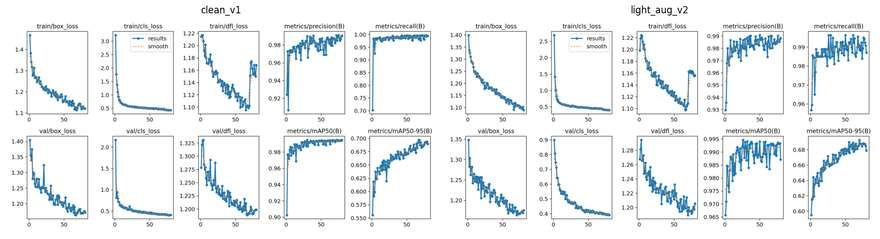

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\04_yolo11n_result_review\grids\training_curves_side_by_side.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (key, run_dir) in zip(axes, RUNS.items()):
    img = cv2.imread(str(run_dir / 'results.png'))
    assert img is not None, run_dir / 'results.png'
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(key)
    ax.axis('off')
plt.tight_layout()
out = GRID_DIR / 'training_curves_side_by_side.png'
plt.savefig(out, dpi=160)
plt.show()
print('saved:', out)


## 5. Confusion Matrix 확인

두 모델 모두 6개 class 자체를 서로 헷갈리는 문제는 거의 없음.

보이는 문제는 주로 background column 쪽임. 이는 class를 잘못 분류했다기보다, 일부 예측이 정답과 매칭되지 않은 false positive로 집계된 것에 가까움.


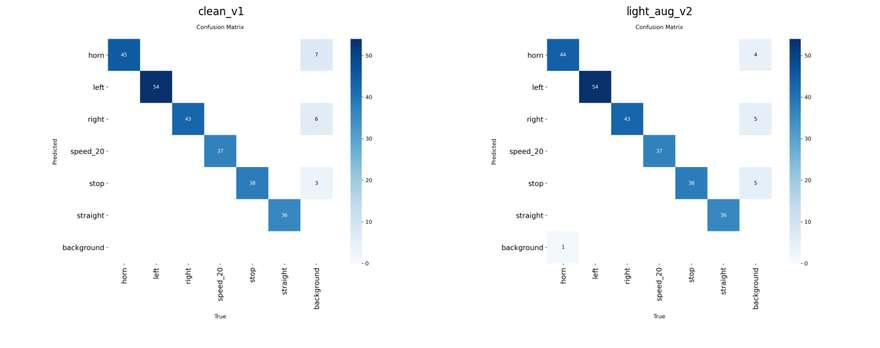

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\04_yolo11n_result_review\grids\confusion_matrix_side_by_side.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (key, run_dir) in zip(axes, RUNS.items()):
    img = cv2.imread(str(run_dir / 'confusion_matrix.png'))
    assert img is not None, run_dir / 'confusion_matrix.png'
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(key)
    ax.axis('off')
plt.tight_layout()
out = GRID_DIR / 'confusion_matrix_side_by_side.png'
plt.savefig(out, dpi=160)
plt.show()
print('saved:', out)


## 6. Prediction Preview 확인

03 노트북에서 test sample prediction을 저장했음.

정렬상 horn 샘플이 먼저 많이 보이지만, confidence와 bbox가 안정적으로 잡히는지 확인 가능함.


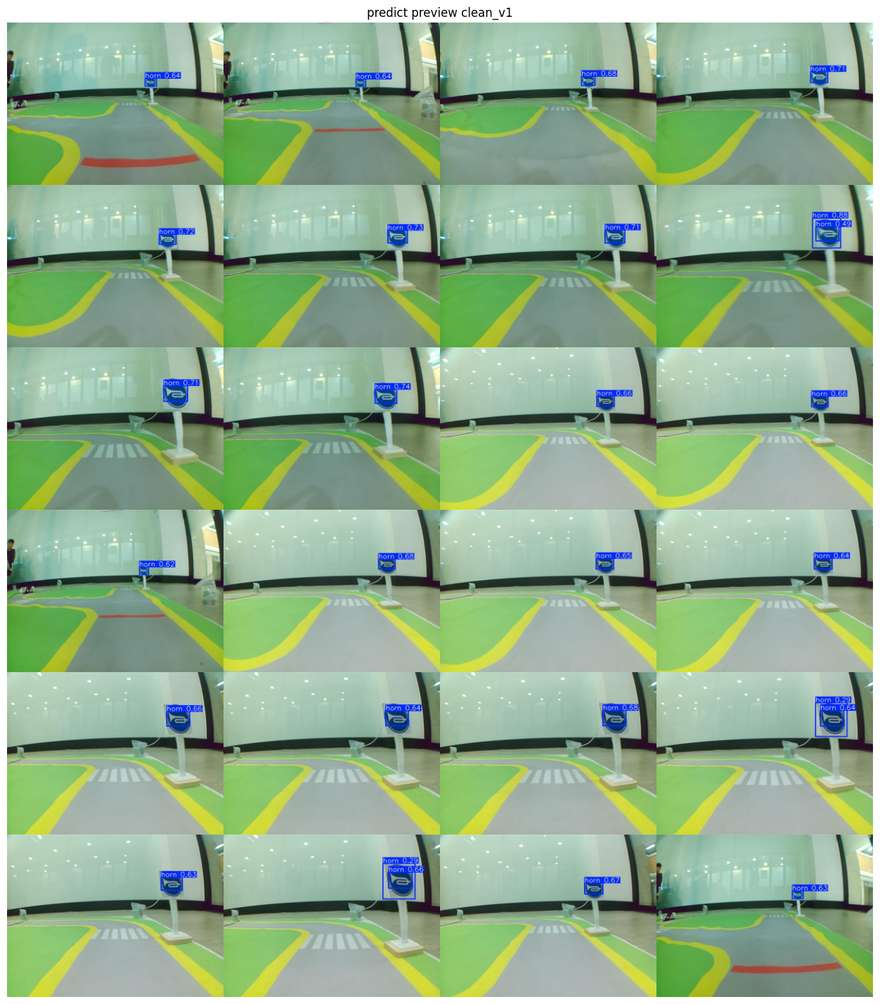

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\04_yolo11n_result_review\grids\predict_preview_clean_v1.jpg


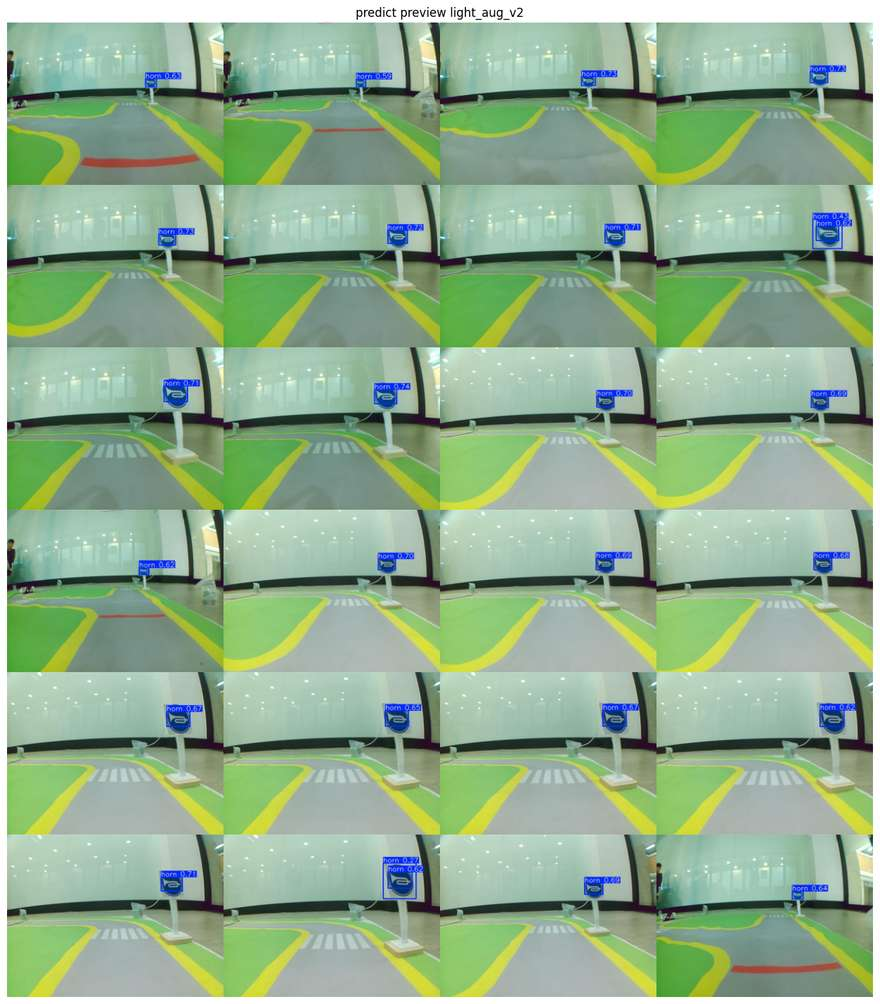

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\04_yolo11n_result_review\grids\predict_preview_light_aug_v2.jpg


In [7]:
def make_preview_grid(image_dir: Path, out_path: Path, title: str, limit=24, cols=4, tile_w=320):
    images = sorted([p for p in image_dir.glob('*.jpg')])[:limit]
    thumbs = []
    for p in images:
        img = cv2.imread(str(p))
        if img is None:
            continue
        h, w = img.shape[:2]
        tile_h = int(h * tile_w / w)
        img = cv2.resize(img, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
        thumbs.append(img)
    if not thumbs:
        print('no preview images:', image_dir)
        return
    rows = int(np.ceil(len(thumbs) / cols))
    tile_h = max(t.shape[0] for t in thumbs)
    canvas = np.full((rows * tile_h, cols * tile_w, 3), 245, dtype=np.uint8)
    for i, t in enumerate(thumbs):
        r, c = divmod(i, cols)
        canvas[r*tile_h:r*tile_h+t.shape[0], c*tile_w:c*tile_w+t.shape[1]] = t
    cv2.imwrite(str(out_path), canvas)
    plt.figure(figsize=(16, max(4, rows * 3)))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()
    print('saved:', out_path)

preview_dirs = {
    'clean_v1': OUTPUT_ROOT / 'predict_test_samples_field2_clean_v1_yolo11n',
    'light_aug_v2': OUTPUT_ROOT / 'predict_test_samples_field2_light_aug_v2_yolo11n',
}
for key, d in preview_dirs.items():
    make_preview_grid(d, GRID_DIR / f'predict_preview_{key}.jpg', f'predict preview {key}')


## 7. 모델 선택

현재 결과 기준으로 최종 후보는 `light_aug_v2`가 더 적합함.

근거:

- test mAP50: clean 0.9931, light-aug 0.9937
- test mAP50-95: clean 0.6973, light-aug 0.7008
- test recall: clean 0.9786, light-aug 0.9945
- 표지판 제어에서는 놓치지 않는 것이 중요하므로 recall 우위가 의미 있음.
- light augmentation은 실제 현장 조명/blur/노이즈 변화에 더 강할 가능성이 있음.

따라서 Pi 속도 테스트와 통합 후보는 우선 `field2_light_aug_v2_yolo11n/weights/best.onnx`로 잡음.


In [8]:
SELECTED_MODEL = {
    'selected_dataset_key': 'light_aug_v2',
    'selected_run_name': 'field2_light_aug_v2_yolo11n',
    'selected_pt': str(RUNS['light_aug_v2'] / 'weights' / 'best.pt'),
    'selected_onnx': str(RUNS['light_aug_v2'] / 'weights' / 'best.onnx'),
    'fallback_pt': str(RUNS['clean_v1'] / 'weights' / 'best.pt'),
    'fallback_onnx': str(RUNS['clean_v1'] / 'weights' / 'best.onnx'),
    'reason': 'light_aug_v2 has slightly better test mAP and recall; recall matters for sign-triggered control.',
    'test_metrics': metric_df.to_dict('records'),
}

selection_path = TABLE_DIR / 'selected_sign_model.json'
selection_path.write_text(json.dumps(SELECTED_MODEL, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(SELECTED_MODEL, ensure_ascii=False, indent=2))
print('saved:', selection_path)


{
  "selected_dataset_key": "light_aug_v2",
  "selected_run_name": "field2_light_aug_v2_yolo11n",
  "selected_pt": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\07_sign_detection_yolo\\colab_outputs\\yolo11n_field2_20260507\\field2_light_aug_v2_yolo11n\\weights\\best.pt",
  "selected_onnx": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\07_sign_detection_yolo\\colab_outputs\\yolo11n_field2_20260507\\field2_light_aug_v2_yolo11n\\weights\\best.onnx",
  "fallback_pt": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\07_sign_detection_yolo\\colab_outputs\\yolo11n_field2_20260507\\field2_clean_v1_yolo11n\\weights\\best.pt",
  "fallback_onnx": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\07_sign_detection_yolo\\colab_outputs\\yolo11n_field2_20260507\\field2_clean_v1_yolo11n\\weights\\best.onnx",
  "reason": "light_aug_v2 has slig

## 8. 실행 결과 메모

이번 단계 결론:

- YOLO11n 표지판 탐지 학습은 성공함.
- clean/aug 모두 성능은 높음.
- 최종 후보는 `light_aug_v2`로 둠.
- 다음 단계는 Pi에서 `best.onnx`의 실제 inference latency를 측정하고, 신호등/차선 모델과 함께 돌릴 때 loop budget에 들어오는지 확인하는 것임.

다음 실험 후보:

1. Pi ONNX Runtime latency 측정
2. 실제 Pi camera frame에서 sign detection preview
3. confidence threshold / detection interval 조정
4. lane model과 병렬 실행 시 CPU 점유/주행 loop 영향 확인
